# Proyecto de Grado: IA al servicio de las comunidades
Maestría en Analítica para la Inteligencia de Negocios

**Nombres:** María Fernanda Izquierdo Aparicio & Ana María Ochoa Muñoz

**Fecha:** 18 de Abril de 2025

Este modelo forma parte del proyecto de grado de la Maestría en Analítica para la Inteligencia de Negocios de la Pontificia Universidad Javeriana, enfocado en la aplicación de Inteligencia Artificial al servicio de las comunidades. Su objetivo es clasificar imágenes de plantas en función de su especie usando una arquitectura pre-entrenada RESNET

## 1. Importe de Librerias

In [4]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import os
import zipfile
import shutil
import seaborn as sns
import datetime
import cv2

import keras
from keras import models
from keras import layers

import random

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras import Layer
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report

from PIL import Image  # Librería para abrir y manipular imágenes

# ignoring warnings
import warnings
warnings.simplefilter("ignore")

In [6]:
#Medir_tiempo_ejecucion():
inicio = datetime.datetime.now()
print(f"Inicio: {inicio.strftime('%Y-%m-%d %H:%M:%S.%f')}")

Inicio: 2025-04-18 20:26:18.262818


## 2. Definción de Rutas y Parámetros

In [9]:
data_dir = 'Datos Finales Balanceados'  # Reemplaza con la ruta real
metadata_file = 'archivos_datos_balanceados.csv' # Reemplaza con la ruta real
image_height = 150
image_width = 150
batch_size = 15
num_classes = None  # Se determinará automáticamente del archivo CSV

## 3. Cargar y procesar los metadatos

In [12]:
try:
    metadata = pd.read_csv(metadata_file, sep=",")
    metadata = metadata.rename(columns={'Nombre del archivo': 'image_id'})
    metadata = metadata.rename(columns={'Carpeta': 'Planta'})
    
    # Asegúrate de que las columnas 'filename' (o el nombre de tu columna de nombres de archivo)
    # y 'label' (o el nombre de tu columna de etiquetas) existan.
   
    if 'image_id' not in metadata.columns or 'Planta' not in metadata.columns:
        raise ValueError("El archivo CSV debe contener las columnas 'image_id' y 'Planta'.")
    class_names = metadata['Planta'].unique().tolist()
    num_classes = len(class_names)
    print(f"Se encontraron {num_classes} clases: {class_names}")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo de metadatos en '{metadata_file}'.")
    exit()
except ValueError as e:
    print(f"Error al procesar el archivo CSV: {e}")
    exit()

Se encontraron 9 clases: ['Apple', 'Strawberry', 'Cauliflower', 'Potato', 'Bean', 'Cucumber', 'Corn_(maize)', 'Tomato', 'Yuca']


In [14]:
train, test= train_test_split(metadata, test_size=0.2, random_state=42,shuffle=True, stratify=metadata['Planta'])
train.shape, test.shape

((43200, 2), (10801, 2))

## 4. Crear un generador de datos

In [17]:
datagen = ImageDataGenerator(
    validation_split = 0.2,
    preprocessing_function = None,
    rotation_range = 45,
    zoom_range = 0.2,
    horizontal_flip = True,
    vertical_flip = True,
    fill_mode = 'nearest',
    shear_range = 0.1,
    height_shift_range = 0.1,
    width_shift_range = 0.1
)

train_generator = datagen.flow_from_dataframe(
    dataframe=train,
    directory=data_dir,
    x_col='image_id',
    y_col='Planta',
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',  # Importante para clasificación multiclase
    subset='training',
    seed=42,
    classes=class_names  # Asegurarse del orden de las clases
)

validation_generator = datagen.flow_from_dataframe(
    dataframe=train,
    directory=data_dir,
    x_col='image_id',
    y_col='Planta',
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    seed=42,
    classes=class_names
)

Found 34559 validated image filenames belonging to 9 classes.
Found 8639 validated image filenames belonging to 9 classes.


## 5. Cargar el modelo ResNet50 preentrenado (sin la capa superior de clasificación)

In [19]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(image_height, image_width, 3))

## 6. Congelar las capas convolucionales base

In [23]:
for layer in base_model.layers:
    layer.trainable = False

## 7. Añadir una nueva capa de clasificación personalizada

In [26]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
# Puedes añadir más capas densas aquí si lo deseas
# x = Dense(1024, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x)

## 8. Crear el modelo final

In [29]:
model = Model(inputs=base_model.input, outputs=predictions)

## 9. Compilar el modelo para fine-tuning de la última capa

In [32]:
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

## 10. Entrenar el modelo con la última capa descongelada

In [35]:
epochs_fine_tune = 20  # Define el número de épocas para el fine-tuning

In [37]:
print("Comenzando el entrenamiento de la última capa...")
history_fine_tune = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=epochs_fine_tune,
    verbose = 1
)

Comenzando el entrenamiento de la última capa...
Epoch 1/20
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 796s 345ms/step - accuracy: 0.9034 - loss: 0.2983 - val_accuracy: 0.9767 - val_loss: 0.0682
Epoch 2/20
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 165s 71ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9777 - val_loss: 0.0639
Epoch 3/20
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 845s 367ms/step - accuracy: 0.9720 - loss: 0.0814 - val_accuracy: 0.9824 - val_loss: 0.0482
Epoch 4/20
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 170s 74ms/step - accuracy: 0.9333 - loss: 0.1660 - val_accuracy: 0.9854 - val_loss: 0.0460
Epoch 5/20
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 872s 378ms/step - accuracy: 0.9796 - loss: 0.0627 - val_accuracy: 0.9806 - val_loss: 0.0533
Epoch 6/20
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 170s 74ms/step - accuracy: 1.0000 - loss: 0.0137 - val_accuracy: 0.9831 - val_loss: 0.0561
Epoch 7/20
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 840s 365ms/step - accuracy: 0.9810 - loss: 0.0563 - val_accuracy: 0.9819 - val_loss: 0.0575
Epoch 8/20
2303/

In [38]:
fin = datetime.datetime.now()
print(f"Fin: {fin.strftime('%Y-%m-%d %H:%M:%S.%f')}")
    
duracion = fin - inicio
print(f"Duración: {duracion}")

Fin: 2025-04-18 23:12:57.420768
Duración: 2:46:39.157950


## 11. Opcional: Descongelar algunas de las últimas capas del modelo base para un fine-tuning más profundo

In [40]:
# unfreeze_layers = 5  # Número de capas a descongelar (contando desde la última convolucional)

# for layer in base_model.layers[-unfreeze_layers:]:
#     layer.trainable = True


## 12. Opcional: Recompilar el modelo después de descongelar las capas

In [42]:
#model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Usar un learning rate menor
#              loss='categorical_crossentropy',
#              metrics=['accuracy'])

## 13. Opcional: Entrenar el modelo con las capas descongeladas

In [44]:
#epochs_deep_fine_tune = 5  # Define el número de épocas para el fine-tuning profundo

#print(f"\nComenzando el fine-tuning profundo de las últimas {unfreeze_layers} capas...")
#history_deep_fine_tune = model.fit(
#    train_generator,
#    steps_per_epoch=train_generator.samples // train_generator.batch_size,
#    validation_data=validation_generator,
#    validation_steps=validation_generator.samples // validation_generator.batch_size,
#    epochs=epochs_deep_fine_tune
#)

## 14. Evaluar el modelo final

In [46]:
print("\nEvaluando el modelo...")
evaluation_result = model.evaluate(validation_generator)
print(f"Pérdida en la validación: {evaluation_result[0]:.4f}")
print(f"Precisión en la validación: {evaluation_result[1]:.4f}")


Evaluando el modelo...
576/576 ━━━━━━━━━━━━━━━━━━━━ 178s 309ms/step - accuracy: 0.9898 - loss: 0.0350
Pérdida en la validación: 0.0399
Precisión en la validación: 0.9883


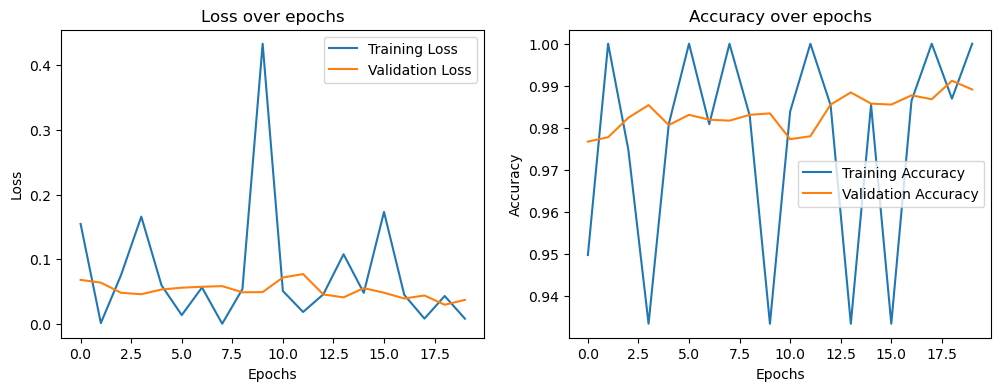

In [47]:
# Acceder a los datos de pérdida y precisión
loss = history_fine_tune.history['loss']
val_loss = history_fine_tune.history['val_loss']
accuracy = history_fine_tune.history['accuracy']
val_accuracy = history_fine_tune.history['val_accuracy']

# Graficar la pérdida del modelo
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_fine_tune.history['loss'], label='Training Loss')
plt.plot(history_fine_tune.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Graficar la precisión del modelo
plt.subplot(1, 2, 2)
plt.plot(history_fine_tune.history['accuracy'], label='Training Accuracy')
plt.plot(history_fine_tune.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [59]:
epochs = [1, 2, 3, 4, 5, 6, 7, 8,9,10,11,12,13,14,15,16,17,18,19,20]
data = {
    'Epoch': epochs,
    'Trainning Loss': loss,
    'Validation Loss': val_loss,
    'Training Accuracy': accuracy,
    'Validation  Accuracy': val_accuracy
}
df = pd.DataFrame(data)

# Imprimir la tabla
print(df)

    Epoch  Trainning Loss  Validation Loss  Training Accuracy  \
0       1        0.154650         0.068187           0.949687   
1       2        0.001404         0.063938           1.000000   
2       3        0.075746         0.048244           0.974757   
3       4        0.165963         0.045997           0.933333   
4       5        0.059760         0.053305           0.980894   
5       6        0.013749         0.056082           1.000000   
6       7        0.056466         0.057549           0.980836   
7       8        0.000407         0.058506           1.000000   
8       9        0.053999         0.049003           0.982891   
9      10        0.433237         0.049330           0.933333   
10     11        0.050976         0.071852           0.983876   
11     12        0.018578         0.077171           1.000000   
12     13        0.045831         0.045666           0.985352   
13     14        0.107776         0.041138           0.933333   
14     15        0.048088

In [61]:
# Accuracy final en entrenamiento
val_loss = history_fine_tune.history['val_loss'][-1]

In [63]:
print('Perdida final en Train:', history_fine_tune.history['loss'][-1])
print("Pérdida final en Validation:", history_fine_tune.history['val_loss'][-1])


print("Accuracy final en Train:", history_fine_tune.history['accuracy'][-1])
print("Accuracy final en Validation:", history_fine_tune.history['val_accuracy'][-1])

Perdida final en Train: 0.008218755945563316
Pérdida final en Validation: 0.03729655221104622
Accuracy final en Train: 1.0
Accuracy final en Validation: 0.9891014695167542


## 15. Testeo del Modelo

In [66]:
test.Planta = test.Planta.astype('str')

test_generator =  datagen.flow_from_dataframe(test,
                         directory = "Datos Finales",
                         subset = "training",
                         x_col = "image_id",
                         y_col = "Planta",
                         target_size = (image_height,image_width),
                         batch_size = batch_size,
                         class_mode = "categorical")

Found 4097 validated image filenames belonging to 9 classes.


In [67]:
# -------------------------
# 1. Obtener predicciones completas para test
# -------------------------
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

274/274 ━━━━━━━━━━━━━━━━━━━━ 78s 281ms/step


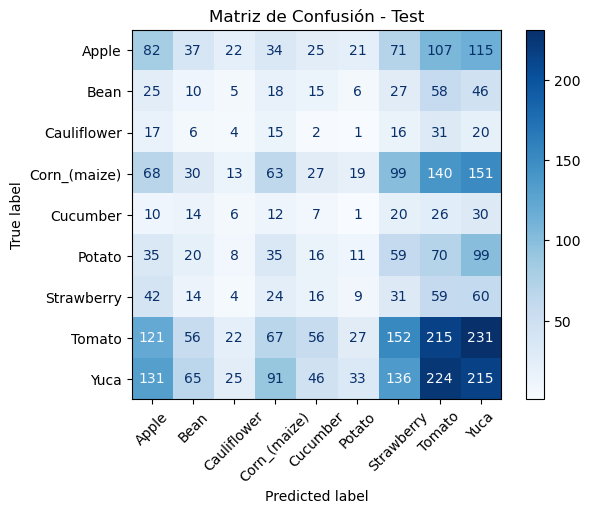

In [69]:
# -------------------------
# 2. Matriz de Confusión
# -------------------------
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión - Test")
plt.show()

In [70]:
accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.1557


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 822ms/step


ValueError: num must be an integer with 1 <= num <= 12, not 13

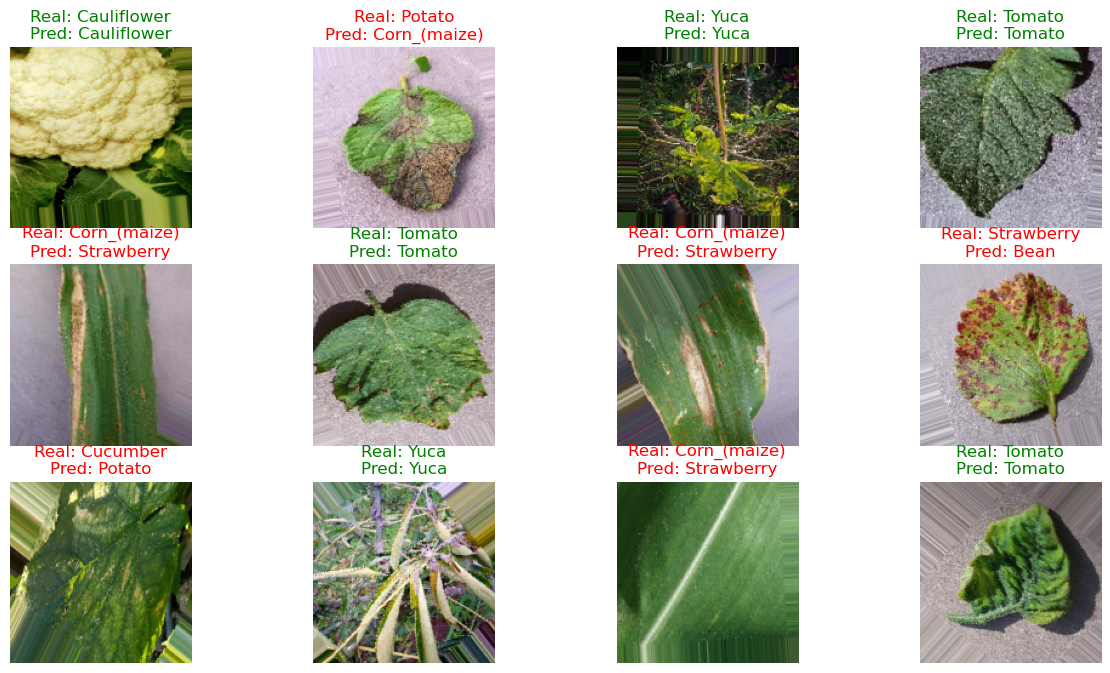

In [71]:
# Función para normalizar imágenes solo para visualización
def normalize_for_display(img):
    img_min = img.min()
    img_max = img.max()
    if img_max > 1.0 or img_min < 0.0:
        img = (img - img_min) / (img_max - img_min + 1e-7)
    return img

# Obtener nombres de clases
class_indices = test_generator.class_indices
class_names = list(class_indices.keys())

# Reiniciar el generador para empezar desde el principio
test_generator.reset()
x_batch, y_true_batch = next(test_generator)

# Obtener predicciones del modelo
y_pred_probs_batch = model.predict(x_batch)
y_pred_batch = np.argmax(y_pred_probs_batch, axis=1)
y_true_batch = np.argmax(y_true_batch, axis=1)

# Número de imágenes a mostrar (máximo el tamaño del batch)
num_samples = x_batch.shape[0]

# Mostrar imágenes con etiquetas
plt.figure(figsize=(15, 8))
for i in range(num_samples):
    plt.subplot(3, 4, i + 1)
    img_to_show = normalize_for_display(x_batch[i])
    plt.imshow(img_to_show)
    plt.axis('off')
    plt.title(
        f"Real: {class_names[y_true_batch[i]]}\nPred: {class_names[y_pred_batch[i]]}",
        color='green' if y_true_batch[i] == y_pred_batch[i] else 'red'
    )
plt.tight_layout()
plt.suptitle("Muestreo de Predicciones vs. Etiquetas Reales", fontsize=16, y=1.02)
plt.show()

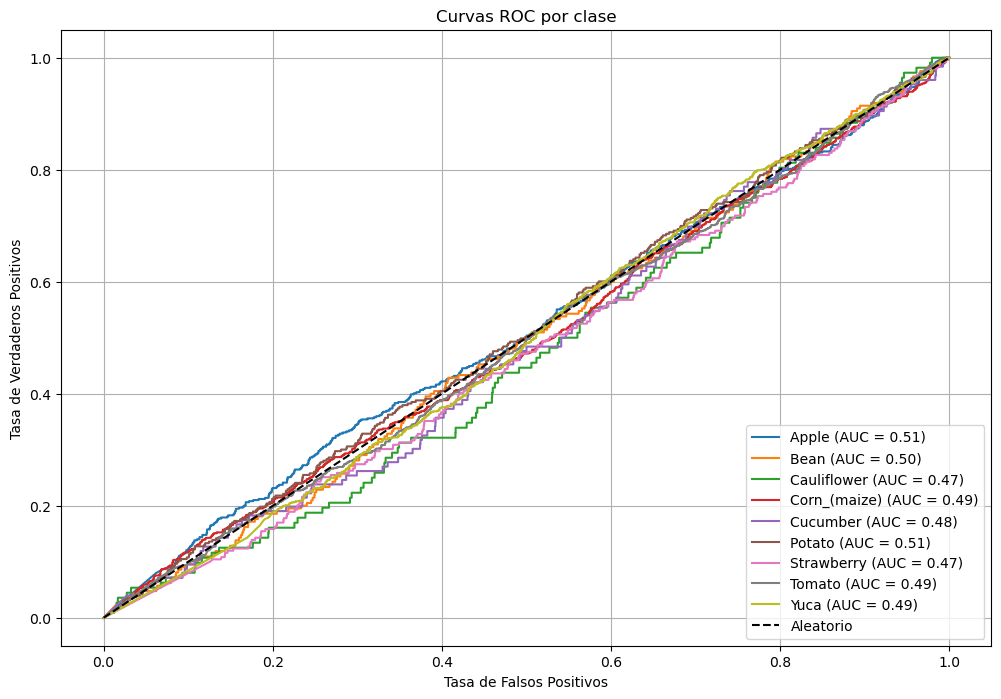

In [77]:
# 3. Convertir etiquetas reales a one-hot
n_classes = y_pred_probs.shape[1]
y_true_onehot = to_categorical(y_true, num_classes=n_classes)

# 4. Calcular ROC y AUC por clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 5. Obtener nombres de clase
class_names = list(test_generator.class_indices.keys())

# 6. Graficar curvas ROC
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC por clase')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [79]:
from sklearn.metrics import roc_auc_score

# AUC macro (promedio de clases, todas igual de importantes)
auc_macro = roc_auc_score(y_true_onehot, y_pred_probs, average='macro')

# AUC micro (promedia sobre todas las instancias)
auc_micro = roc_auc_score(y_true_onehot, y_pred_probs, average='micro')

print(f"AUC Macro promedio: {auc_macro:.4f}")
print(f"AUC Micro promedio: {auc_micro:.4f}")


AUC Macro promedio: 0.4915
AUC Micro promedio: 0.5243


In [81]:
# Asegúrate de tener esto:
# y_pred = np.argmax(y_pred_probs, axis=1)
# y_true = test_generator.classes

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# F1 Scores
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_micro = f1_score(y_true, y_pred, average='micro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score (macro): {f1_macro:.4f}")
print(f"F1 Score (micro): {f1_micro:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")

# Detalle por clase
class_names = list(test_generator.class_indices.keys())
print("\nReporte de clasificación por clase:")
print(classification_report(y_true, y_pred, target_names=class_names))


Accuracy: 0.1557
F1 Score (macro): 0.1085
F1 Score (micro): 0.1557
F1 Score (weighted): 0.1574

Reporte de clasificación por clase:
              precision    recall  f1-score   support

       Apple       0.15      0.16      0.16       514
        Bean       0.04      0.05      0.04       210
 Cauliflower       0.04      0.04      0.04       112
Corn_(maize)       0.18      0.10      0.13       610
    Cucumber       0.03      0.06      0.04       126
      Potato       0.09      0.03      0.05       353
  Strawberry       0.05      0.12      0.07       259
      Tomato       0.23      0.23      0.23       947
        Yuca       0.22      0.22      0.22       966

    accuracy                           0.16      4097
   macro avg       0.11      0.11      0.11      4097
weighted avg       0.17      0.16      0.16      4097



## 16. Guardar el modelo entrenado

In [84]:
model.save('modelo_9_resnet50_balanceado_fine_tuned.h5')